In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import jsonlines
import re 
import pandas as pd
import glob
from itertools import groupby
import re 
from itertools import groupby
import jsonlines
import os

In [2]:
final_matching_df = pd.read_csv('cache/final-matching-articles-and-meetings.csv', index_col=0)
csvs_method_1 = sorted(glob.glob('../data/city-council-meeting-minutes/audio-files/parsed-transcripts/large-v2-output-*/*-1.csv'))
csvs_method_2 = sorted(glob.glob('../data/city-council-meeting-minutes/audio-files/parsed-transcripts/large-v2-output-*/*-2.csv'))
transcribed_text_files = sorted(glob.glob('../data/city-council-meeting-minutes/audio-files/parsed-transcripts/large-v2-output-*/*.txt'))

In [4]:
## csv index method 1: is the bottom-half index. Contains only hyperlinked lines.
## csv index method 2: is the right-side index. Contains more of the list (although it seems it doesn't contain hierarchy).
# get the lengths of the MP3 files from the server
mp3_lengths_cmd = ! ssh spangher@pluslab02.isi.edu \
    'ls /lfs1/spangher/newsworthiness/scripts-agendawatch-data/whisper-transcription/data/large-v2-output-*-mp3s/* | \
    xargs -I {} /usr/local/bin/python3.9 -c "from mutagen.mp3 import MP3; audio = MP3(\"{}\"); print(\"{}\", audio.info.length)"'

In [5]:
mp3_lengths = mp3_lengths_cmd[1:]
mp3_length_df = pd.DataFrame(list(map(lambda x: x.split(), mp3_lengths)), columns=["file", "length"])
mp3_length_df = (
    mp3_length_df
        .assign(clip_id=lambda df: df['file'].str.split('/').str.get(-1).apply(lambda x: re.search(r'clip-(\d+)', x).group(1)).astype(int))
        .assign(year=lambda df: df['file'].str.split('/').str.get(-2).str.replace('-mp3s', ''))
        .assign(length=lambda df: df['length'].astype(float))
)

In [3]:
# groupby clip
all_transcribed_text_dfs = []
errors = []
for clip_id, files in groupby(transcribed_text_files, lambda x: re.search('clip-(\d+)', x)[1]):
    files = sorted(files, key=lambda x: re.search('part-(\d+)', x)[1])
    transcribed_dfs = []
    prev_stop_time = 0
    for fname in files:
        with open(fname) as f:
            lines_df = pd.DataFrame(list(jsonlines.Reader(f)))
            if len(lines_df) == 0:
                errors.append({'clip_id': clip_id, 'file': fname, 'error': 'no lines'})
                continue
            lines_df['start'] = lines_df['start'] + prev_stop_time
            lines_df['end'] = lines_df['end'] + prev_stop_time
            prev_stop_time = lines_df['end'].max()
            transcribed_dfs.append(lines_df)
    if len(transcribed_dfs) > 0:
        all_transcribed_text_dfs.append(pd.concat(transcribed_dfs).assign(clip_id=clip_id))
        
errors_df = pd.DataFrame(errors)

In [4]:
all_transcribed_text_dfs[0]

,start,end,text,clip_id
0,0.00,10.26,right?,16593
1,10.26,27.68,Ah boy.,16593
2,27.68,31.60,Good afternoon.,16593
3,31.60,36.28,Welcome to the 42nd inaugural meeting of the ...,16593
4,36.28,37.96,City and County of San Francisco.,16593
...,...,...,...,...
135,8823.48,8826.88,"Madam Clerk, is there any more business in fr...",16593
136,8826.88,8829.12,"That concludes our business for today, Mr. Pr...",16593
137,8829.12,8830.88,"Ladies and gentlemen, we are adjourned.",16593
138,8830.88,8832.92,Thank you.,16593


In [5]:
full_transcribed_text_df = (
    pd.concat(all_transcribed_text_dfs)
        .assign(clip_id=lambda df: df['clip_id'].astype(int))
)

# determine the end-time for each fully-transcribed clip
max_times_per_clip = (
    full_transcribed_text_df
    .groupby('clip_id')['end'].max()
)

if False:
    # merge the max times with the mp3 length df
    mp3_length_df_with_transcription_data = (
        mp3_length_df
        .loc[lambda df: ~df['file'].str.contains('part')]
        .merge(
                max_times_per_clip.to_frame('transcribed_end_time'),
                left_on='clip_id',
                right_index=True
            )
    )

    # filter out clips where the transcription length is too short
    acceptable_transcriptions = (
        mp3_length_df_with_transcription_data
        .loc[lambda df: df['length'] - df['transcribed_end_time'] < 100]
    )

In [26]:
orig_files_to_fetch = glob.glob('../data/city-council-meeting-minutes/all-links-to-pdfs-in-bay-area/*/*-san-francisco*.csv')
all_files_to_fetch = pd.concat(list(map(lambda x: pd.read_csv(x, index_col=0), orig_files_to_fetch)))

In [27]:
orig_video_bos_files_to_fetch = (
    all_files_to_fetch
        .loc[lambda df: df['doc_type'] == 'Video']
        .loc[lambda df: df['committee'] == 'Board of Supervisors']
        # .iloc[0].to_dict()
        .assign(clip_id=lambda df: df['url'].str.extract(r'clip/(\d+)', expand=False))
        .loc[lambda df: df['clip_id'].notnull()]
        .assign(clip_id=lambda df: df['clip_id'].astype(int))
)

In [10]:
redo_lengths = (
    pd.DataFrame([{'end': 4458.12, 'clip_id': '16735'}, {'end': 7656.14, 'clip_id': '16767'}, {'end': 16222.259999999998, 'clip_id': '16923'}, {'end': 8238.32, 'clip_id': '17099'}, {'end': 10810.98, 'clip_id': '17235'}, {'end': 17010.88, 'clip_id': '17359'}, {'end': 12262.24, 'clip_id': '17587'}, {'end': 15097.840000000002, 'clip_id': '17784'}, {'end': 21957.739999999998, 'clip_id': '18036'}, {'end': 11410.3, 'clip_id': '18540'}, {'end': 14579.840000000002, 'clip_id': '18840'}, {'end': 12276.980000000001, 'clip_id': '18962'}, {'end': 6749.9, 'clip_id': '19254'}, {'end': 6258.200000000001, 'clip_id': '19305'}, {'end': 15057.06, 'clip_id': '19491'}, {'end': 18650.199999999997, 'clip_id': '19695'}, {'end': 11151.16, 'clip_id': '19792'}, {'end': 10795.779999999999, 'clip_id': '20253'}, {'end': 17727.46, 'clip_id': '20699'}, {'end': 5715.86, 'clip_id': '21067'}, {'end': 14540.579999999998, 'clip_id': '21142'}, {'end': 8143.4400000000005, 'clip_id': '21741'}, {'end': 8117.06, 'clip_id': '22297'}, {'end': 12329.2, 'clip_id': '22424'}, {'end': 11427.539999999999, 'clip_id': '22791'}, {'end': 11704.44, 'clip_id': '23003'}, {'end': 13813.34, 'clip_id': '23143'}, {'end': 10370.66, 'clip_id': '23925'}, {'end': 26974.68, 'clip_id': '24774'}, {'end': 15127.760000000002, 'clip_id': '24989'}, {'end': 24011.159999999996, 'clip_id': '25297'}, {'end': 18127.08, 'clip_id': '25344'}, {'end': 15792.08, 'clip_id': '25777'}, {'end': 30992.180000000008, 'clip_id': '25889'}, {'end': 14009.500000000002, 'clip_id': '25922'}, {'end': 11345.259999999998, 'clip_id': '26700'}, {'end': 25060.120000000006, 'clip_id': '26763'}, {'end': 17249.120000000003, 'clip_id': '26999'}, {'end': 27102.660000000007, 'clip_id': '27241'}, {'end': 17147.239999999998, 'clip_id': '27351'}, {'end': 11406.800000000001, 'clip_id': '27679'}, {'end': 11902.180000000002, 'clip_id': '27952'}, {'end': 14654.199999999999, 'clip_id': '28089'}, {'end': 16486.46, 'clip_id': '28658'}, {'end': 23237.8, 'clip_id': '28699'}, {'end': 7145.24, 'clip_id': '28981'}, {'end': 8797.220000000001, 'clip_id': '29051'}, {'end': 9013.42, 'clip_id': '29199'}, {'end': 14761.259999999998, 'clip_id': '31073'}, {'end': 19892.140000000003, 'clip_id': '31607'}, {'end': 16857.78, 'clip_id': '31789'}, {'end': 23112.98, 'clip_id': '32000'}, {'end': 13491.8, 'clip_id': '35152'}, {'end': 23879.12, 'clip_id': '39071'}, {'end': 19603.800000000003, 'clip_id': '39719'}, {'end': 10504.94, 'clip_id': '39823'}, {'end': 17064.68, 'clip_id': '40379'}, {'end': 6317.34, 'clip_id': '40435'}, {'end': 22667.019999999997, 'clip_id': '40499'}, {'end': 17936.739999999998, 'clip_id': '40562'}, {'end': 18661.920000000002, 'clip_id': '40667'}, {'end': 18242.54, 'clip_id': '40850'}, {'end': 9579.16, 'clip_id': '40993'}, {'end': 15168.760000000002, 'clip_id': '41233'}, {'end': 12905.62, 'clip_id': '41358'}, {'end': 17880.839999999997, 'clip_id': '41432'}, {'end': 13452.9, 'clip_id': '41583'}, {'end': 10436.5, 'clip_id': '41643'}, {'end': 6567.599999999999, 'clip_id': '41836'}, {'end': 26877.460000000006, 'clip_id': '42114'}, {'end': 13013.34, 'clip_id': '42283'}, {'end': 777.08, 'clip_id': '42440'}])
        .assign(clip_id=lambda df: df['clip_id'].astype(int))
        .rename(columns={'end': 'redo_transcribed_end_time'})
)

In [11]:
mp3_length_df_with_transcription_data_and_file_data = (
    mp3_length_df_with_transcription_data
        .merge(orig_video_bos_files_to_fetch[['clip_id', 'date', 'url']], on='clip_id', how='inner')
        .assign(time_diff=lambda df: df['length'] - df['transcribed_end_time'])
)

In [103]:
transcribed_file_df = (
    pd.DataFrame(transcribed_text_files, columns=['file'])
        .assign(clip_id=lambda df: df['file'].apply(lambda x: re.search('clip-(\d+)', x)[1], ))
        .assign(part=lambda df: df['file'].apply(lambda x: re.search('part-(\d+)', x)[1], ).astype(int))
        .assign(file_size=lambda df: df['file'].apply(os.path.getsize))
)

### List transcriptions that we want to redo

In [765]:
clip_ids_with_short_files = (
    transcribed_file_df
        .loc[lambda df: df['file_size'] < 100]['clip_id'].astype(int)
        # .isin(mp3_length_df_with_transcription_data_and_file_data['clip_id'])
        # .sum()
)
clip_ids_with_incomplete_parts = (
    mp3_length_df
        .loc[lambda df: df['file'].str.contains('part')]
        ['clip_id']
        .drop_duplicates()
        # .isin(mp3_length_df_with_transcription_data_and_file_data['clip_id'])
)
(mp3_length_df_with_transcription_data_and_file_data
    .loc[lambda df: 
            df['clip_id'].isin(pd.concat([clip_ids_with_short_files, clip_ids_with_incomplete_parts]))
            | (df['time_diff'] > 100)
        ]
).to_csv('../scripts-agendawatch-data/whisper-transcription/data/redo-transcriptions.csv')

# Use the outlines scraped from the websites

In [28]:
all_outline_csv_dfs = []

for f in csvs_method_2:
    if open(f).read() != '':
        clip_id = re.search(r'clip-(\d+)', f).group(1)
        csv_df = pd.read_csv(f, index_col=0)
        csv_df['clip_id'] = int(clip_id)
        all_outline_csv_dfs.append(csv_df)

### Try to build classifier to fill in the gaps with bad time-markers

In [29]:
## for each index-csv, get the board outline note that is non-zero.
full_outlines_df = pd.concat(all_outline_csv_dfs).reset_index(drop=True)
significant_times_by_clip = (
    full_outlines_df
        .loc[lambda df: df['time'].notnull()]
        .groupby('clip_id')
        ['time']
        .aggregate(list)
)

## filter the transcribed text to only include texts that total length matches the length of mp3s.
full_transcribed_text_df_clean = (
    full_transcribed_text_df
        # .loc[lambda df: df['clip_id'].isin(acceptable_transcriptions['clip_id'])]
)

## assign transcribed text lines to their position in the outline, if there is one.
full_transcribed_text_df_clean= (
    full_transcribed_text_df_clean
    .merge(significant_times_by_clip.to_frame('significant_times'), left_on='clip_id', right_index=True)
    .assign(significant_times=lambda df: df
        .apply(lambda x: list(filter(lambda y: x['start'] <= y <= x['end'], x['significant_times'])), axis=1)
    )
)

In [30]:
(full_transcribed_text_df_clean
 ['significant_times']
 .str.len()
 .pipe(lambda s: s > 0)
 .value_counts()
 .pipe(lambda s: s/s.sum()) 
)

False    0.995077
True     0.004923
Name: significant_times, dtype: float64

In [31]:
## construct training dataset
first_round_pos = full_transcribed_text_df_clean.loc[lambda df: df['significant_times'].str.len() == 1]
first_round_neg = full_transcribed_text_df_clean.loc[lambda df: df['significant_times'].str.len() == 0].sample(len(first_round_pos))
label_df = pd.concat([
    first_round_pos.assign(label=1),
    first_round_neg.assign(label=0)
]).sample(frac=1)

In [32]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
import os 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

lr_pipe_round_1 = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=.005, max_df=.5, stop_words='english')),
    ('lr', LogisticRegressionCV(Cs=10, cv=5, max_iter=2000, n_jobs=-1))
])

In [33]:
f1_scores = []
accs = []
for _ in range(10):
    train_df, test_df = train_test_split(label_df, test_size=.1)
    lr_pipe_round_1.fit(X=train_df['text'], y=train_df['label'])
    y_pred = lr_pipe_round_1.predict(test_df['text'])
    f1_scores.append(f1_score(test_df['label'], y_pred))
    accs.append(accuracy_score(test_df['label'], y_pred))

In [34]:
full_transcribed_text_df_clean['proba'] = lr_pipe_round_1.predict_proba(full_transcribed_text_df_clean['text'])[:, 1]

In [36]:
(full_transcribed_text_df_clean
 .pipe(lambda df: roc_auc_score(y_true=df['significant_times'].str.len() > 0, y_score=df['proba']))
)

0.844365562646213

In [ ]:
f1_scores_cal = []
y_true = full_transcribed_text_df_clean['significant_times'].str.len() > 0
for cutoff in np.arange(0, 1, .01):
    y_pred = (full_transcribed_text_df_clean['proba'] > cutoff)
    f1_scores_cal.append({'cutoff': cutoff, 'score': f1_score(y_true=y_true, y_pred=y_pred)})

In [38]:
pd.DataFrame(f1_scores_cal).loc[lambda df: df['score'].idxmax()]

cutoff    0.820000
score     0.149492
Name: 82, dtype: float64

In [59]:
import pandas as pd 
pd.options.display.max_colwidth = 300
top_items =(full_transcribed_text_df_clean
 .sort_values('proba', ascending=False)['text']
 .head(20)
 .tolist()
)

In [65]:
formatted = []
for t in top_items:
    formatted.append(t + '\\\\')

In [67]:
import pyperclip
pyperclip.copy('\n'.join(formatted))

In [40]:
full_outlines_df_for_processing = (
    full_outlines_df
        .assign(proposal_number=lambda df: df['text']
                    .str.split().str.get(0)
                    .apply(lambda x: x if isinstance(x, str) and x.isdigit() and (len(x) == 6) else np.nan).astype(float)
                )
)
full_transcribed_text_df_clean = full_transcribed_text_df_clean.reset_index().set_index('clip_id')
# acceptable_transcriptions = acceptable_transcriptions.reset_index().set_index('clip_id')

In [41]:
from tqdm.auto import tqdm

# see how many times in the index are out of order.
full_outlines_df_for_processing['time'].fillna(method='ffill').pipe(lambda s: s - s.shift(1)).pipe(lambda s: s >= 0).value_counts()

True     53555
False     1786
Name: time, dtype: int64

In [778]:
full_filled_in_csvs = infer_and_fill_in_missing_time_values(full_outlines_df_for_processing, full_transcribed_text_df_clean, acceptable_transcriptions)

100%|██████████| 1341/1341 [00:09<00:00, 137.19it/s]


In [779]:
full_filled_in_csvs = (
    full_filled_in_csvs    
        .assign(proposal_number=lambda df: df['text']
                    .str.split().str.get(0)
                    .apply(lambda x: x if isinstance(x, str) and x.isdigit() and (len(x) == 6) else np.nan).astype(float)
    )
)

In [1312]:
(
    full_filled_in_csvs
        .pipe(lambda df: df['end_time'] - df['time'])
        .quantile(.75)
)

44.0

In [781]:
(
    full_filled_in_csvs
        .loc[lambda df: df['proposal_number'].isnull()]
        .pipe(lambda df: df['end_time'] - df['time'])
        .quantile(.75)
)

21.920000000000073

In [1061]:
# get rows where at least 1 word is uppercase and it's not a proposal
full_outlines_df_for_processing_with_only_headers = (
    full_outlines_df_for_processing
        .loc[lambda df: df.apply(find_header, axis=1)]
        .assign(text=lambda df: df['text'].str.strip().apply(header_to_category))
)

headers_only_csvs = infer_and_fill_in_missing_time_values(
    full_outlines_df_for_processing_with_only_headers, 
    full_transcribed_text_df_clean,
    acceptable_transcriptions
)

headers_only_csvs = headers_only_csvs.drop(columns='proposal_number').assign(total_time=lambda df: df['end_time'] - df['time'])

median_times_by_category = (
    headers_only_csvs
        .loc[lambda df: df['text'].isin(df['text'].value_counts().loc[lambda s: s > 100].index)]
        .groupby('text')['total_time']
        .median()
        .sort_values(ascending=False)
        .pipe(lambda s: s/(60))
)

median_times_by_category

''

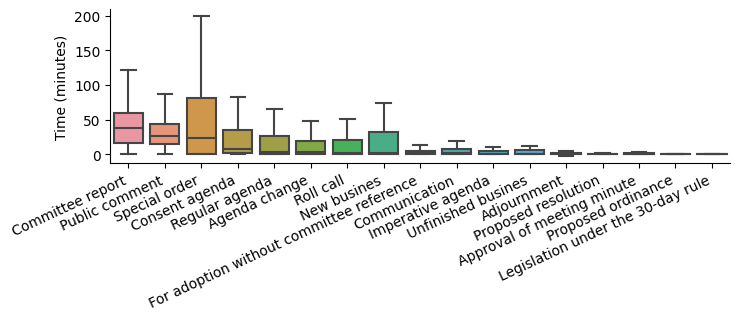

In [1052]:
_, ax = plt.subplots(figsize=(8, 2))
(
    headers_only_csvs
        .loc[lambda df: df['text'].isin(df['text'].value_counts().loc[lambda s: s > 100].index)]
        .assign(total_time=lambda df: df['total_time'] / 60)
        .pipe(lambda df: sns.boxplot(
            data=df,
            x='text',
            y='total_time',
            showfliers=False,
            order=median_times_by_category.index,
            ax=ax
        )
    )
        .set_xticklabels(median_times_by_category.index.str.capitalize(), rotation=25, horizontalalignment='right') 
)
plt.xlabel('')
plt.ylabel('Time (minutes)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
;

# Match to linked dataset

In [831]:
import numpy as np

In [857]:
# link audio transcripts to the `matching_df`, which matches city council proposals to SF Chronicle articles
# 1. first, train models using only the acceptable transcripts, because these might be higher quality
# 2. if not, use the full set of transcripts, which might be misaligned

In [832]:
final_matching_df['File #'].isin(full_outlines_df_for_processing['proposal_number'].dropna().astype(int)).value_counts()
(final_matching_df
    .loc[lambda df: ~df['File #'].isin(full_outlines_df_for_processing['proposal_number'].dropna().astype(int))]
    ['meeting date']
    .pipe(pd.to_datetime).dt.year.value_counts()
    # .sum()
)

File #
True     1747
False     254
Name: count, dtype: int64

In [728]:
(
    final_matching_df
        .loc[lambda df: ~df['File #'].isin(full_outlines_df_for_processing['proposal_number'].dropna().astype(int))]
        .loc[lambda df: pd.to_datetime(df['meeting date']).dt.year == 2022]
        .sort_values('meeting date')
        [['meeting text', 'summary_text']]
        .iloc[-1].to_dict()
)

{'meeting text': 'Departmental Overdose Prevention Policies - Annual Submission - 2022. Resolution receiving Overdose Prevention Policies for the Department of Public Health, Department of Homelessness and Supportive Housing, Healthy Streets Operation Center through the Department of Emergency Management, and the Human Services Agency describing how the department and its grantees that provide direct services to clients who use drugs will promote strategies to reduce drug overdoses, submitted as required by Administrative Code, Section 15.17.',
 'summary_text': "As a former member of the San Francisco Board of Supervisors, he sponsored legislation that forced the city Department of Homelessness and Supportive Housing and its contractors to develop standard overdose prevention guidelines.\n\nAssembly Member Matt Haney knows firsthand how fast and easy access to opioid reversal medication can mean the difference between life and death for overdose victims. Haney said he was walking in Sa

In [858]:
final_matching_df['File #'].isin(full_filled_in_csvs['proposal_number'].dropna().astype(int)).value_counts()

File #
True     1362
False     639
Name: count, dtype: int64

In [1025]:
full_filled_in_csvs['header'] = np.nan 

In [1026]:
prev_header = None
prev_clip = None
full_filled_in_csvs_with_headers = full_filled_in_csvs.reset_index(drop=True)
for idx, row in full_filled_in_csvs_with_headers.sort_values(['clip_id', 'time']).iterrows():
    if row['clip_id'] != prev_clip:
        prev_header = None
        prev_clip = row['clip_id']

    if find_header(row):
        prev_header = row['text']
    full_filled_in_csvs_with_headers.loc[idx, 'header'] = prev_header
full_filled_in_csvs_with_headers['header'] = full_filled_in_csvs_with_headers['header'].apply(header_to_category)

In [1027]:
transcript_parts_to_match = []
for _, (clip_id, start_time, end_time) in tqdm(full_filled_in_csvs[['clip_id', 'time', 'end_time']].iterrows(), total=len(full_filled_in_csvs)):
    transcribed_text_segment = (
        full_transcribed_text_df_clean
            .loc[clip_id]
            .assign(end=lambda df: df['start'].tolist()[1:] + [df['end'].max()])
            .loc[lambda df: (
                ((df['start'] <= start_time) & (df['end'] >= start_time)) | 
                ((df['start'] <= end_time) & (df['end'] >= end_time)) | 
                ((df['start'] >= start_time) & (df['end'] <= end_time))
            )]
            .pipe(lambda df: ' '.join(df['text'].tolist()))
    )
    transcript_parts_to_match.append(transcribed_text_segment)

100%|██████████| 36373/36373 [00:29<00:00, 1224.20it/s]


In [1036]:
full_filled_in_csvs_with_headers['transcribed_text'] = transcript_parts_to_match

In [1037]:
full_filled_in_csvs_with_newsworthiness = (
    full_filled_in_csvs_with_headers
        .loc[lambda df: df['proposal_number'].notnull()]
        .assign(label=lambda df: df['proposal_number'].isin(final_matching_df['File #']))
)

### Examine time and length of each section of the meeting

In [1093]:
meeting_section_and_proposal_stats = (
    headers_only_csvs['text'].value_counts()
    .to_frame('Common meeting sections')
    .join(full_filled_in_csvs_with_newsworthiness['header'].value_counts().to_frame('Proposals by meeting section'))
    .fillna(0)
    .assign(**{'Proposals per meeting section': lambda df: df['Proposals by meeting section'] / df['Common meeting sections']})
    .head(20)
    .sort_values('Proposals per meeting section', ascending=False)
    .loc[lambda df: df['Common meeting sections'] > 100]
)

In [1609]:
meeting_section_and_proposal_stats[['Proposals per meeting section']]

,Proposals per meeting section
text,
SPECIAL ORDER,7.890110
REGULAR AGENDA,5.287723
FOR ADOPTION WITHOUT COMMITTEE REFERENCE,5.109434
COMMITTEE REPORT,4.175532
CONSENT AGENDA,3.939655
LEGISLATION UNDER THE 30-DAY RULE,2.731778
PROPOSED RESOLUTION,2.569038
IMPERATIVE AGENDA,1.954545
PROPOSED ORDINANCE,1.035714


In [1096]:
## proportion of newsworthy proposals per section
(
    full_filled_in_csvs_with_newsworthiness
        .assign(header=lambda df: df['header'].apply(lambda x: x if x in meeting_section_and_proposal_stats.index else 'OTHER'))
        .groupby('header')['label']
        .mean()
        .sort_values(ascending=False) 
)

header
COMMITTEE REPORT                            0.133758
LEGISLATION UNDER THE 30-DAY RULE           0.127535
SPECIAL ORDER                               0.101671
AGENDA CHANGE                               0.100000
APPROVAL OF MEETING MINUTE                  0.095238
FOR ADOPTION WITHOUT COMMITTEE REFERENCE    0.089365
PUBLIC COMMENT                              0.078125
REGULAR AGENDA                              0.070897
OTHER                                       0.067133
ADJOURNMENT                                 0.065764
CONSENT AGENDA                              0.056893
ROLL CALL                                   0.048495
PROPOSED ORDINANCE                          0.044335
COMMUNICATION                               0.038961
IMPERATIVE AGENDA                           0.036822
PROPOSED RESOLUTION                         0.024430
Name: label, dtype: float64

In [1097]:
## amount of time spent in each section 
(
    full_filled_in_csvs_with_newsworthiness
        .assign(header=lambda df: df['header'].apply(lambda x: x if x in meeting_section_and_proposal_stats.index else 'OTHER'))
        .assign(total_time=lambda df: df['end_time'] - df['time'])
        .groupby('header')['total_time'].median().sort_values(ascending=False)
)

header
REGULAR AGENDA                              123.00
AGENDA CHANGE                                62.50
COMMITTEE REPORT                             31.00
OTHER                                        20.00
SPECIAL ORDER                                 9.63
FOR ADOPTION WITHOUT COMMITTEE REFERENCE      6.54
COMMUNICATION                                 5.00
PUBLIC COMMENT                                3.00
CONSENT AGENDA                                1.00
ADJOURNMENT                                   0.00
APPROVAL OF MEETING MINUTE                    0.00
IMPERATIVE AGENDA                             0.00
LEGISLATION UNDER THE 30-DAY RULE             0.00
PROPOSED ORDINANCE                            0.00
PROPOSED RESOLUTION                           0.00
ROLL CALL                                     0.00
Name: total_time, dtype: float64

In [1098]:
(full_filled_in_csvs_with_newsworthiness
    .assign(header=lambda df: df['header'].apply(lambda x: x if x in meeting_section_and_proposal_stats.index else 'OTHER'))
    .assign(total_time=lambda df: df['end_time'] - df['time'])
    .groupby(['header', 'label'])
    ['total_time']
    .median()
    .unstack()
)

label,False,True
header,,
ADJOURNMENT,0.00,10.00
AGENDA CHANGE,72.74,14.00
APPROVAL OF MEETING MINUTE,0.00,1.78
COMMITTEE REPORT,30.00,63.00
COMMUNICATION,6.30,0.00
CONSENT AGENDA,1.00,0.00
FOR ADOPTION WITHOUT COMMITTEE REFERENCE,6.20,10.14
IMPERATIVE AGENDA,0.00,0.00
LEGISLATION UNDER THE 30-DAY RULE,0.00,0.00


### Examine time of segments by label

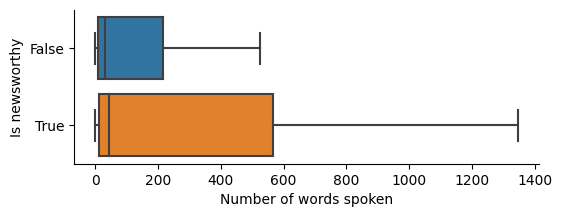

In [931]:
_, ax = plt.subplots(figsize=(6, 2))
(
    full_filled_in_csvs_with_newsworthiness
        .assign(text_len=lambda df: df['transcribed_text'].str.split().str.len())
        .assign(label=lambda df: df['label'].astype(str))
        .pipe(lambda df: sns.boxplot(data=df, y='label', x='text_len', showfliers=False, ax=ax))
)
plt.xlabel('Number of words spoken')
plt.ylabel('Is newsworthy')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False) 

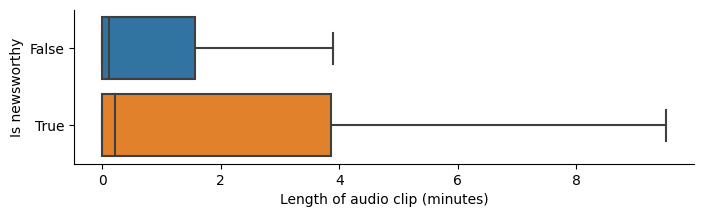

In [1613]:
_, ax = plt.subplots(figsize=(8, 2))
(
    full_filled_in_csvs_with_newsworthiness
        .assign(total_time=lambda df: (df['end_time'] - df['time']).abs() / 60)
        .assign(label=lambda df: df['label'].astype(str))
        .pipe(lambda df: sns.boxplot(data=df, y='label', x='total_time', showfliers=False, ax=ax))
)
plt.xlabel('Length of audio clip (minutes)')
plt.ylabel('Is newsworthy')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

### Model newsworthiness using transcribed text

In [1136]:
# downsample 
from sklearn.pipeline import Pipeline
# from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import CountVectorizer

lr_pipe_newsworthiness = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    # ('cv', CountVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    # ('bal', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))
])

In [1363]:
full_filled_in_csvs_with_newsworthiness_with_date = (
    full_filled_in_csvs_with_newsworthiness
        .merge(
                # orig_video_bos_files_to_fetch[['clip_id', 'date']],
                (all_files_to_fetch
                    .loc[lambda df: df['doc_type'] == 'Video']
                    .assign(clip_id=lambda df: df['url'].str.extract(r'clip/(\d+)', expand=False))
                    .loc[lambda df: df['clip_id'].notnull()]
                    .assign(clip_id=lambda df: df['clip_id'].astype(int))
                    [['clip_id', 'date']]
                ),
                on='clip_id',
                how='left'
        )
)

# get sample weights based on class imbalance
df_to_train = (
    full_filled_in_csvs_with_newsworthiness_with_date
        .pipe(
            lambda df: df.merge(
                                df['label']
                                    .value_counts(normalize=True)
                                    .pipe(lambda s: 1-s),
                                left_on='label',
                                right_index=True
                    )
    )
)

test_df = df_to_train.loc[lambda df: df['date']  > '2021-01-01']
train_df = df_to_train.loc[lambda df: df['date']  <= '2021-01-01']
lr_pipe_newsworthiness.fit(train_df['transcribed_text'], train_df['label'], lr__sample_weight=train_df['proportion'])

In [1401]:
test_df['y_prob'] = lr_pipe_newsworthiness.predict_proba(test_df['transcribed_text'])[:, 1]

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_96627/496088805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['y_prob'] = lr_pipe_newsworthiness.predict_proba(test_df['transcribed_text'])[:, 1]


In [1402]:
cal_scores = []
for k in np.arange(0, 1, .01):
    y_pred = test_df['y_prob'] > k
    s = f1_score(test_df['label'], y_pred)
    cal_scores.append(s)

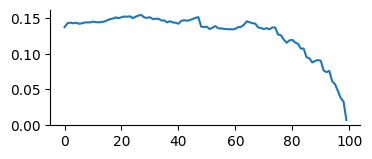

In [1403]:
ax = pd.Series(cal_scores).plot(figsize=(4,1.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

In [1621]:
roc_auc_score(test_df['label'], test_df['y_prob'])

0.5593462555962556

In [1458]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

In [1533]:
# top k for each day
metric = f1_score
metric = recall_score
# metric = accuracy_score
# metric = precision_score
diff_ks = []
for k in range(0, 20):
        res = (   test_df
                .groupby('date')
                .apply(lambda df: 
                        df
                                .sort_values('y_prob', ascending=False)
                                # .sample(frac=1)
                                .assign(y_pred=lambda df: ([1] * k + [0] * (len(df) - k))[:len(df)])
                                .assign(y_rand=lambda df: df['y_pred'].sample(frac=1).values)
                                .pipe(lambda df:
                                                np.nan if (df['label'] == 0).all() else 
                                        {'model_derived': metric(df['label'], df['y_pred']), 'random': metric(df['label'], df['y_rand'])}
                                )
                )
                .dropna()
                .pipe(lambda df: pd.DataFrame(df.tolist()))
                .mean()
        )
        res = res.to_dict()
        res['k'] = k
        diff_ks.append(res)
        

In [1623]:
res_df.iloc[5]

model_derived    0.476171
random           0.323309
Name: 5, dtype: float64

In [1630]:
import pyperclip
pyperclip.copy(str(res_df.to_dict(orient='records')))

Text(0, 0.5, 'Recall')

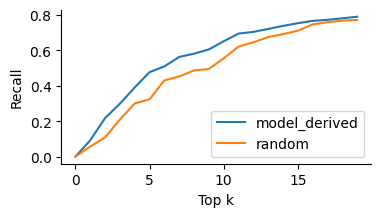

In [1539]:
res_df = pd.DataFrame(diff_ks)[['model_derived', 'random']]
ax = res_df.plot(figsize=(4,2))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('Top k')
plt.ylabel('Recall')

In [1546]:
res_df.assign(diff=(lambda df: df['model_derived'] - df['random'])).loc[lambda df: df.sort_values('diff', ascending=False).index[0]]

model_derived    0.476171
random           0.323309
diff             0.152862
Name: 5, dtype: float64

In [1491]:
# mean roc auc over the time period.
k = 3
(   test_df
        .groupby('date')
        .apply(lambda df: 
                df
                    .pipe(lambda df: np.nan if (df['label'].unique().shape[0] == 1) else roc_auc_score(df['label'], df['y_prob']))
        )
        # .pipe(lambda s: (s - .5).abs() + .5)
        # .mean()
        .median()
        # .hist()
)

0.6183173076923077

In [1556]:
test_df.assign(total_time=lambda df: (df['end_time'] - df['time']).abs() / 60)[['total_time', 'label', 'y_prob']].corr()

,total_time,label,y_prob
total_time,1.000000,0.074465,-0.076713
label,0.074465,1.000000,0.056028
y_prob,-0.076713,0.056028,1.000000


In [1560]:
test_df.assign(total_words=lambda df: df['transcribed_text'].str.split().apply(len))[['total_words', 'label', 'y_prob']].corr()

,total_words,label,y_prob
total_words,1.000000,0.073375,-0.076724
label,0.073375,1.000000,0.056028
y_prob,-0.076724,0.056028,1.000000


### Test using time as the only feature

In [1595]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

lr_time_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

lr_time_pipe.fit(train_df.pipe(lambda df: df['end_time'] - df['time']).to_frame(), train_df['label'], lr__sample_weight=train_df['proportion'])
# lr_reg.fit(train_df.pipe(lambda df: df['end_time'] - df['time']).to_frame(), train_df['label'])

Pipeline(steps=[('scaler', StandardScaler()), ('lr', LogisticRegression())])

In [1598]:
time_y_pred = lr_time_pipe.predict(test_df.pipe(lambda df: df['end_time'] - df['time']).to_frame())

In [1599]:
f1_score(test_df['label'], time_y_pred)

0.1475237091675448

In [1600]:
(test_df['label'] == time_y_pred).mean()

0.7865435356200527

In [1170]:
(df_to_train
    .groupby('proposal_number')[['transcribed_text', 'label']]
    .aggregate(list)
    .assign(transcribed_text=lambda df: df['transcribed_text'].apply(lambda x: ' '.join(x)))
    .assign(label=lambda df: df['label'].apply(lambda x: 1 if any(x) else 0))
    # .groupby('label')['transcribed_text'].apply(lambda s: s.str.len()).groupby(level=0).median()
)

,transcribed_text,label
proposal_number,,
90258.0,"Good afternoon, Supervisors. My name is Keith...",0
110548.0,"controls for awnings, canopies, and marquees ...",0
110674.0,Item number four is a hearing on the Interage...,0
111278.0,but I'm going to start with one person and an...,0
120062.0,an important role in our city's quality of li...,0
...,...,...
230460.0,"It shall be noted on the resolution, same hou...",0
230461.0,I hope you will all join us in voting to pass...,0
230462.0,Mandelman eyes supervisor Melgar Melgar eyes ...,0


In [1183]:
# percentage of the meeting that is newsworthy
full_filled_in_csvs_with_newsworthiness.groupby('clip_id')['label'].mean().round(1).value_counts().sort_index()

label
0.0    582
0.1    281
0.2    125
0.3     40
0.4     21
0.5     18
0.6      2
0.7      2
0.8      1
1.0      7
Name: count, dtype: int64

In [1602]:
## open questions:
## ---------------------------------------------------------------------------------------------

## 1. Language of proposals, news articles, transcribed audio
##     a. how does the language of transcribed audio differ from the language of the proposals?
##     b. is the language of the news articles more similar to the language of the proposals or the transcribed audio?

##### DONE 
## 2. What is the accuracy of the top k proposals per meeting? 
##    how many proposals are typically covered each meeting?

## 3. construct the training dataset also by using the date the article was published...
##     i.e. only label `1` to items that were discussed in the meeting nearest to the article.

## fine-tune GPT models:
##    1. proposal text only
##    2. transcribed audio only
##    3. proposal text + transcribed audio
##    4. proposal text + transcribed audio + time spent

## 4. regardless of when proposals get discussed, what are the times in the meeting where the language is the most similar to proposals? 
##      i.e. when do proposals get discussed in ways that are NOT explicitly mentioned underneath their proposal number?

In [70]:
full_meeting_row_df = pd.read_csv('cache/2023-04-13__full_meeting_row_df.csv')

In [71]:
# number of proposals filed per meeting
(
    full_meeting_row_df
        .loc[lambda df: df['committee'] == 'Board of Supervisors']
        .value_counts(['date', 'committee'])
        .round(-1)
        .value_counts()
        .sort_index()
)

0      14
10      3
20      2
30      7
40     33
50     58
60     93
70     54
80     66
90     29
100    26
110    12
120     6
130     5
150     1
160     1
dtype: int64

In [179]:
# proposal coverage (how many proposals are covered by the news articles?)
# here, proposals are the text descriptions downloaded from SFBOS,
# and coverage is defined as the number of proposals that are mentioned in the news articles
covered_proposals_by_date = (
    full_meeting_row_df
            .loc[lambda df: df['committee'] == 'Board of Supervisors']
            .drop_duplicates(['date', 'File #'])    
            .assign(date=lambda df: pd.to_datetime(df['date']).dt.date)
            .value_counts('date')
            .pipe(lambda s: pd.concat([
                    s.to_frame('all proposals'),
                    final_matching_df
                        .assign(**{'meeting date': lambda df: pd.to_datetime(df['meeting date']).dt.date})
                        .drop_duplicates(['meeting date', 'summary_text'])
                        .drop_duplicates(['meeting date', 'File #'])
                        ['meeting date']
                        .value_counts()
                        .to_frame('covered proposals')
                ], axis=1)
            )
            .fillna(0).astype(int)
)
coverage_percentage = (
    covered_proposals_by_date
        .loc[lambda df: df['all proposals'] > 10]
        .assign(perc_covered_proposals=lambda df: df['covered proposals'] / df['all proposals'])
        .sort_values('perc_covered_proposals', ascending=False)
)

In [73]:
(
    coverage_percentage['covered proposals']
        .value_counts().loc[lambda s: s > 10]
        .to_frame('# covered proposals by meeting')
        .sort_index()
)

,# covered proposals by meeting
0,87
1,90
2,66
3,59
4,39
5,26
6,14


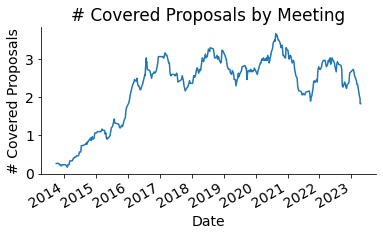

In [82]:
import datetime
import matplotlib.pyplot as plt 
plt.rc('font', size=14)

ax = (
    covered_proposals_by_date
        .reset_index().assign(index=lambda df: pd.to_datetime(df['index'])).set_index('index')
        # .loc[lambda df: df.index > datetime.datetime(2014, 1, 1)]
        .sort_index()['covered proposals']
        # pandas running window
        .rolling(30)
        .mean()
        .plot(figsize=(6,3), title='# Covered Proposals by Meeting')
)
ax.spines['right'].set_visible(False)   
ax.spines['top'].set_visible(False)
ax.set_ylabel('# Covered Proposals')
ax.set_xlabel('Date')
plt.savefig('../latex/emnlp2023/figures/num-covered-by-meeting.png')

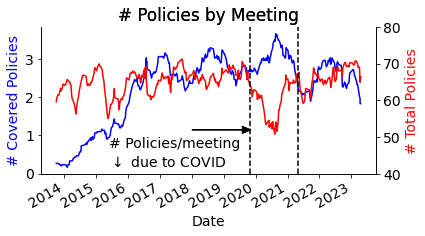

In [143]:
import datetime
import matplotlib.pyplot as plt 
plt.rc('font', size=14)


df_to_plot = (
    covered_proposals_by_date
        .reset_index().assign(index=lambda df: pd.to_datetime(df['index'])).set_index('index')
        # .loc[lambda df: df.index > datetime.datetime(2014, 1, 1)]
        .sort_index()
)

ax1 = (df_to_plot['covered proposals']
                # pandas running window
                .rolling(30)
                .mean()
                .plot(figsize=(6,3), title='# Policies by Meeting', color='blue')
      )
ax2 = ax1.twinx()
(       df_to_plot['all proposals']
                # pandas running window
                .rolling(30)
                .mean()
                .plot(figsize=(6,3), title='# Policies by Meeting', ax=ax2, color='r', ylim=(40,80))
)


import matplotlib.dates as md
from datetime import datetime
ymin, ymax = plt.ylim()
x0 = md.date2num(datetime(2018, 1, 1))
x1 = md.date2num(datetime(2019, 8, 1))
plt.arrow(
    x0,
    52,
    x1 - x0, 
    0,
    edgecolor='black',
    facecolor='black',
    head_length=100,
    head_width=2
)
plt.vlines(datetime(2019, 11, 1), ymin, ymax, linestyles='dashed', color='black')
plt.vlines(datetime(2021, 5, 1), ymin, ymax, linestyles='dashed', color='black')
plt.text(datetime(2015, 6, 1), 47, s='# Policies/meeting')
plt.text(datetime(2015, 6, 1), 42, s='$\downarrow$ due to COVID')
plt.ylim((ymin, ymax))


# ax.spines['right'].set_visible(False)   
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.set_ylabel('# Covered Policies', color='blue')
ax2.set_ylabel("# Total Policies", color='r', fontsize=14)

ax1.set_xlabel('Date')
plt.savefig('../latex/emnlp2023/figures/num-covered-by-meeting.png')

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_41654/1991071013.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])


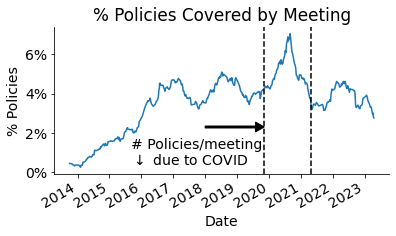

In [161]:
ax = (covered_proposals_by_date
        .reset_index().assign(index=lambda df: pd.to_datetime(df['index'])).set_index('index')
        # .loc[lambda df: df.index > datetime.datetime(2014, 1, 1)]
        .sort_index()
 .assign(cov=lambda df: df['covered proposals'].rolling(30).mean())
 .assign(num=lambda df: df['all proposals'].rolling(30).mean()) 
 .apply(lambda x: x['cov'] / x['num'], axis=1)
#  .rolling(30)
#  .mean()
 .plot(figsize=(6,3), title='% Policies Covered by Meeting')
)

import matplotlib.dates as md
from datetime import datetime
ymin, ymax = plt.ylim()
x0 = md.date2num(datetime(2018, 1, 1))
x1 = md.date2num(datetime(2019, 8, 1))
plt.arrow(
    x0,
    .023,
    x1 - x0, 
    0,
    edgecolor='black',
    facecolor='black',
    head_length=100,
    head_width=.005
)
plt.vlines(datetime(2019, 11, 1), ymin, ymax, linestyles='dashed', color='black')
plt.vlines(datetime(2021, 5, 1), ymin, ymax, linestyles='dashed', color='black')
plt.text(datetime(2015, 9, 4), .012, s='# Policies/meeting')
plt.text(datetime(2015, 9, 4), .004, s='$\downarrow$ due to COVID')
plt.ylim((ymin, ymax))


vals = ax.get_yticks()
ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Date')
ax.set_ylabel('% Policies')
plt.savefig('../latex/emnlp2023/figures/perc-covered-by-meeting.png')

In [183]:
covered_proposals_by_date.index = list(map(str, pd.to_datetime(covered_proposals_by_date.index)))

In [200]:
covered_proposals_by_date.sort_index().loc['2020-01-01':'2020-09-01']['all proposals'].mean()

52.23529411764706

In [191]:
covered_proposals_by_date.sort_index().loc[:'2020-01-01']['all proposals'].mean()
:'2022-01-01'

64.46863468634686

# Diarization

In [7]:
from pyannote.audio import Pipeline
from pyannote.audio import Model, Inference

pipeline = Pipeline.from_pretrained("pyannote/speaker-diarization")


In [19]:
# ffmpeg -i input.mp3 -acodec pcm_s16le -ac 1 -ar 16000 output.wav

fname= '../data/city-council-meeting-minutes/audio-files/example-files/audio-clip-26652.wav'

In [ ]:
# 4. apply pretrained pipeline
diarization = pipeline(fname)

# 5. print the result
for turn, _, speaker in diarization.itertracks(yield_label=True):
    print(f"start={turn.start:.1f}s stop={turn.end:.1f}s speaker_{speaker}")

# Slosh

In [1633]:
import requests
import json
import random
from urllib.parse import urlparse, urljoin
from io import BytesIO
import gzip
import time

In [1635]:
with gzip.open('../../press-releases/data/open-sourced-articles/nytimes-cc-business-articles-to-fetch.txt.gz') as f:
    lines = f.read().decode('utf-8').splitlines()

In [1638]:
import re 
get_key = lambda x: re.sub('\{.*\}', '', x).strip()
get_json_body = lambda x: re.search('\{.*\}', x)[0]

In [1663]:
json_strs = list(map(get_json_body, lines))
page_data = []
for line in json_strs:
    try:
        page_data.append(json.loads(line))
    except:
        continue 

In [1675]:
page_data_200 = list(filter(lambda x: x.get('status') == '200', page_data))

In [1676]:
page_datum = page_data_200[0]

In [1677]:
CC_PREFIX = 'https://data.commoncrawl.org/'

def req_cc(filename, offset, offset_end):
    return requests.get(
        CC_PREFIX + filename,
        headers={
            'Range': 'bytes={}-{}'.format(offset, offset_end),
        }
    )


In [1678]:
import time 

In [1679]:
offset, length = int(page_datum['offset']), int(page_datum['length'])
offset_end = offset + length - 1
resp = req_cc(page_datum['filename'], offset, offset_end)

# retry if 503...
num_attempts = 0
while (resp.status_code == 503) and (num_attempts < 5):
    print('503 status code, requerying...')
    time.sleep(5)
    resp = req_cc(page_datum['filename'], offset, offset_end)
    num_attempts += 1

if resp.status_code > 399:
    pass 

raw_data = BytesIO(resp.content)
f = gzip.GzipFile(fileobj=raw_data)
data = f.read()
warc, header, html = data.decode().strip().split('\r\n\r\n', 2)


In [1681]:
from bs4 import BeautifulSoup
soup = BeautifulSoup( html )

In [1684]:
page_datum

{'url': 'https://www.nytimes.com/guides/business/manage-a-successful-team?rref=collection/sectioncollection/business-smallbusiness&action=click&contentCollection=smallbusiness&region=stream&module=stream_unit&version=latest&contentPlacement=1&pgtype=sectionfront&redirect=true',
 'mime': 'text/html',
 'mime-detected': 'text/html',
 'status': '200',
 'digest': '2443JKXICUR7YEB4ITHGMRGDWMPYH2DF',
 'length': '54091',
 'offset': '948811321',
 'filename': 'crawl-data/CC-MAIN-2023-06/segments/1674764499891.42/warc/CC-MAIN-20230131222253-20230201012253-00297.warc.gz',
 'charset': 'UTF-8',
 'languages': 'eng'}

In [1685]:
CONTAINER_URLS = [
    "https://common-crawl-scrape-v1-ukvxfz3sya-uw.a.run.app",
    'https://common-crawl-scrape-v1-2-ukvxfz3sya-ue.a.run.app',
    'https://common-crawl-scrape-v1-3-ukvxfz3sya-uc.a.run.app',
    'https://common-crawl-scrape-v1-4-ukvxfz3sya-wl.a.run.app',
    'https://common-crawl-scrape-v1-5-ukvxfz3sya-wm.a.run.app',
    'https://common-crawl-scrape-v1-6-ukvxfz3sya-wn.a.run.app',
]

In [1694]:
page_datum

{'url': 'https://www.nytimes.com/guides/business/manage-a-successful-team?rref=collection/sectioncollection/business-smallbusiness&action=click&contentCollection=smallbusiness&region=stream&module=stream_unit&version=latest&contentPlacement=1&pgtype=sectionfront&redirect=true',
 'mime': 'text/html',
 'mime-detected': 'text/html',
 'status': '200',
 'digest': '2443JKXICUR7YEB4ITHGMRGDWMPYH2DF',
 'length': '54091',
 'offset': '948811321',
 'filename': 'crawl-data/CC-MAIN-2023-06/segments/1674764499891.42/warc/CC-MAIN-20230131222253-20230201012253-00297.warc.gz',
 'charset': 'UTF-8',
 'languages': 'eng'}

In [1718]:
datetime.datetime.now().isoformat()

'2023-05-16T18:39:20.459595'

In [1714]:
page_datum['scrape_timestamp'] = str(datetime.datetime.now())
page_datum['article_url'] = page_datum['url'].split('?')[0]

In [1716]:
from requests_futures.sessions import FuturesSession
with FuturesSession(max_workers=1) as session:
    res = session.post(
        CONTAINER_URLS[1],
        headers={'Content-Type': 'application/json'},
        data=json.dumps(page_datum)
    )

In [52]:
import time 
class Timer():
    def __init__(self):
        self.start = time.time()

    def __call__(self, step_name=None, step_artifact=None, file=None):
        step_name = '' if step_name is None else step_name
        file = '' if file is None else file
        print(f'{file},  {step_name}: {str(time.time() - self.start)}')


In [45]:
from functools import partial

In [46]:
p = partial(Timer(), file='test')

In [50]:
p()

test: 3.8445699214935303


In [54]:
3600 / (60 * 60)

1.0

In [58]:
from pyannote.audio import Pipeline
pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization", use_auth_token='<REDACTED>',    
    segmentation_step=.5
)

TypeError: from_pretrained() got an unexpected keyword argument 'segmentation_step'

In [63]:
pipeline._embedding

In [64]:
pipeline.embedding_exclude_overlap

True

In [66]:
from pyannote.audio.pipelines.speaker_diarization import SpeakerDiarization

In [76]:
s = SpeakerDiarization(
    clustering="AgglomerativeClustering"
)

In [82]:
pipeline.segmentation_step = .5 

In [94]:
top_level_params = {
    'clustering': 'AgglomerativeClustering', 
    'embedding': 'speechbrain/spkrec-ecapa-voxceleb',
    'embedding_batch_size': 128,
    'embedding_exclude_overlap': True,
    'segmentation': 'pyannote/segmentation@2022.07',
    'segmentation_batch_size': 128,
    'use_auth_token': '<REDACTED>',
    "segmentation_step": 0.5,
}
pipeline = SpeakerDiarization(**top_level_params)
low_level_params = {
    'clustering': 
        {'method': 'centroid', 'min_cluster_size': 10, 'threshold': 0.7153814381597874},
    'segmentation': 
        {'min_duration_off': 0.5817029604921046, 'threshold': 0.4442333667381752}
}
pipeline.instantiate(low_level_params)